# Instalação de depedencias e configuração

In [26]:
!pip install numpy matplotlib scikit-learn pandas
!pip install --upgrade pip

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets as datasets
import pandas as pd
import pickle

In [28]:
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('dark_background')

# Dataset

In [29]:
#data set
x, y = datasets.make_moons(n_samples=500, noise=0.05)

In [30]:
print(f'{x.shape = }, {y.shape = }')

x.shape = (500, 2), y.shape = (500,)


In [31]:
pd.DataFrame({'x_1': x[:, 0], 'x_2': x[:, 1], 'y': y})

,x_1,x_2,y
0,0.709830,-0.501719,1
1,1.996753,0.178510,1
2,1.701868,-0.275974,1
3,-0.995302,0.193433,0
4,1.193102,-0.500193,1
...,...,...,...
495,-0.976416,0.062191,0
496,1.704281,-0.159129,1
497,-1.041607,-0.027748,0
498,0.054734,1.016572,0


In [32]:
unique = np.unique(y, return_counts=True)
for label, qt_label in zip(unique[0], unique[1]):
    print(f'label: {label}\t Counts: {qt_label}')

label: 0	 Counts: 250
label: 1	 Counts: 250


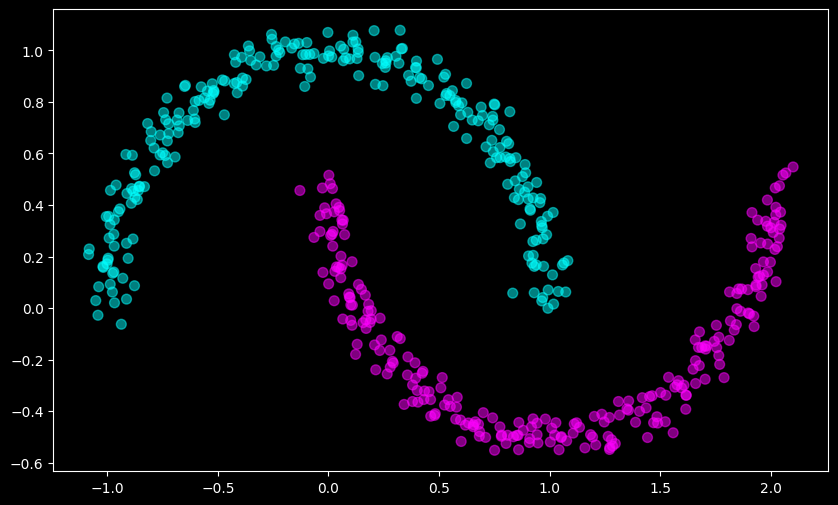

In [33]:
plt.scatter(x[:, 0], x[:, 1], c=y, s=50, alpha=0.5, cmap='cool')

# Modelo

In [47]:
class NnModel:
    def __init__(self, x: np.ndarray, y: np.ndarray, hidden_neurons: int = 10, output_neurons: int = 2):
        np.random.seed(8)
        self.x = x
        self.y = y
        self.hidden_neurons = hidden_neurons
        self.output_neurons = output_neurons
        self.input_neurons = self.x.shape[1]

        # inicializa os pesos e bias
        # Xavier inicialization -> variação uniforme dos pesos
        self.W1 = np.random.randn(self.input_neurons, self.hidden_neurons) / np.sqrt(self.input_neurons)
        self.B1 = np.zeros((1, self.hidden_neurons))
        self.W2 = np.random.randn(self.hidden_neurons, self.output_neurons) / np.sqrt(self.hidden_neurons)
        self.B2 = np.zeros((1, self.output_neurons))
        self.model_dict = {'W1': self.W1, 'B1': self.B1, 'W2': self.W2, 'B2': self.B2}
        self.z1 = 0
        self.f1 = 0

    def forward(self, x: np.ndarray) -> np.ndarray:
        # Equação da reta
        self.z1 = x.dot(self.W1) + self.B1

        # Função de ativação (1)
        self.f1 = np.tanh(self.z1)

        # Equação da reta (2)
        z2 = self.f1.dot(self.W2) + self.B2

        # Softmax
        exp_values = np.exp(z2)
        softmax = exp_values / np.sum(exp_values, axis=1, keepdims=True)
        return softmax

    def loss(self, softmax: np.ndarray) -> np.ndarray:
        # Cross Entropy
        predictions = np.zeros(self.y.shape[0])
        for i, correct_index in enumerate(self.y):
            predicted = softmax[i][correct_index]
            predictions[i] = predicted
        log_prob = -np.log(predicted)
        return log_prob/self.y.shape[0]


    def backpropagation(self, softmax: np.ndarray, learning_rate: float) -> None:

        pass

    def fit(self):
        pass

In [48]:
modelo = NnModel(x, y, hidden_neurons=10, output_neurons=2)
softmax = modelo.forward(x)
modelo.loss(softmax)

np.float64(0.002993755021387988)